# Purpose

This script is used to apply the 4 timseries cross-validation models to the the test data (2015/2022). This instances uses the tiny model (fewer features) than the operational model

In [2]:
#high level modules
import os
import importlib
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# custom modules
fun_dir = "/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/functions/"

def import_from_path(module_name, file_path):
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module

import_from_path("universals", os.path.join(fun_dir, "universal_functions.py"))
from universals import load_pickle_file, twotemp_labels_features_test, predict_2_values_test, return_test_error_metrics

import_from_path("vis", os.path.join(fun_dir, "vis_functions.py"))
from vis import ts_plot, create_scatter_plot_test

We need to read in the transformed test data, apply the models, and save the resictions.

In [4]:
# import test data
file_path = os.path.expanduser("/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/operational_model/data/")

test_fn = os.path.join(file_path, "test.csv")
with open(test_fn) as f:
    test = pd.read_csv(f, sep=',')

# arrange the data by date
test['date'] = pd.to_datetime(test['date'])
test = test.sort_values(by='date')

# reduce to fewer variables to match tiny model names/dims
drop_cols = ['total_solar_radiation_m2', 'mean_rel_hum_m2', 
       'pump_cfs_m2', 'pump_cfs_m3', 'nf_cfs_m2', 'nf_cfs_m3', 'nf_cfs_m4',
       'chipmunk_cfs_m2', 'chipmunk_cfs_m3', 'chipmunk_cfs_m4']

test = test.drop(columns = drop_cols)

And read in the z score mean/sd values.

In [5]:
transform = pd.read_csv("/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/data/mu_sigma.csv", index_col=0)

t_mean_1m = transform['mean'].get('mean_1m_temp_degC')
t_std_1m = transform['sd'].get('mean_1m_temp_degC')

t_mean_05m = transform['mean'].get('mean_0_5m_temp_degC')
t_std_05m = transform['sd'].get('mean_0_5m_temp_degC')

And we'll mimic zero, mid-pump (220), and full pump (550) values to see if the network is sensitive

In [6]:
t_pump_mean = transform["mean"].get("pump_cfs")
t_pump_sd = transform["sd"].get("pump_cfs")
zero_pump = (0 - t_pump_mean) / t_pump_sd
twotwenty_pump = (220 - t_pump_mean) / t_pump_sd
full_pump = (550 - t_pump_mean) / t_pump_sd

test_nopump = test.copy()
test_nopump["pump_cfs_m1"] = zero_pump
test_midpump = test.copy()
test_midpump["pump_cfs_m1"] = twotwenty_pump
test_fullpump = test.copy()
test_fullpump["pump_cfs_m1"] = full_pump

Now we need to apply the models to the test data, but first we need to format the data for the models

In [7]:
test_features, test_labels = twotemp_labels_features_test(test)
test_nopump_features, test_nopump_labels = twotemp_labels_features_test(test_nopump)
test_midpump_features, test_midpump_labels = twotemp_labels_features_test(test_midpump)
test_fullpump_features, test_fullpump_labels = twotemp_labels_features_test(test_fullpump)

Load the models

In [8]:
# load the models
model_dir = '/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/tiny_model/dump/five_ten/'

models = [f for f in os.listdir(model_dir) if 'history' not in f]
models.sort()

model_1 = load_pickle_file(models[0], model_dir)
model_2 = load_pickle_file(models[1], model_dir)
model_3 = load_pickle_file(models[2], model_dir)
model_4 = load_pickle_file(models[3], model_dir)


Now we need to apply the models to the test data and get the resictions, for which we also need the standarization parameters to back calculate.

In [9]:

test["pred_1m_1"], test["pred_05m_1"] = predict_2_values_test(model_1, test_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test["pred_1m_2"], test["pred_05m_2"] = predict_2_values_test(model_2, test_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test["pred_1m_3"], test["pred_05m_3"] = predict_2_values_test(model_3, test_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test["pred_1m_4"], test["pred_05m_4"] = predict_2_values_test(model_4, test_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)

test_nopump["pred_1m_1"], test_nopump["pred_05m_1"] = predict_2_values_test(model_1, test_nopump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test_nopump["pred_1m_2"], test_nopump["pred_05m_2"] = predict_2_values_test(model_2, test_nopump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test_nopump["pred_1m_3"], test_nopump["pred_05m_3"] = predict_2_values_test(model_3, test_nopump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test_nopump["pred_1m_4"], test_nopump["pred_05m_4"] = predict_2_values_test(model_4, test_nopump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)

test_midpump["pred_1m_1"], test_midpump["pred_05m_1"] = predict_2_values_test(model_1, test_midpump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test_midpump["pred_1m_2"], test_midpump["pred_05m_2"] = predict_2_values_test(model_2, test_midpump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test_midpump["pred_1m_3"], test_midpump["pred_05m_3"] = predict_2_values_test(model_3, test_midpump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test_midpump["pred_1m_4"], test_midpump["pred_05m_4"] = predict_2_values_test(model_4, test_midpump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)

test_fullpump["pred_1m_1"], test_fullpump["pred_05m_1"] = predict_2_values_test(model_1, test_fullpump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test_fullpump["pred_1m_2"], test_fullpump["pred_05m_2"] = predict_2_values_test(model_2, test_fullpump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test_fullpump["pred_1m_3"], test_fullpump["pred_05m_3"] = predict_2_values_test(model_3, test_fullpump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
test_fullpump["pred_1m_4"], test_fullpump["pred_05m_4"] = predict_2_values_test(model_4, test_fullpump_features, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)


2025-05-21 16:14:26.406938: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


And now, let's make the ensemble prediction to assess the model performance, only for the control model (where we don't change the pumping).

In [10]:
test["ts_cv_ensemble_pred_1m"] = np.mean(test[['pred_1m_1', 'pred_1m_2', 'pred_1m_3', 'pred_1m_4']], axis=1)
test["ts_cv_ensemble_pred_05m"] = np.mean(test[['pred_05m_1', 'pred_05m_2', 'pred_05m_3', 'pred_05m_4']], axis=1)

In order to compare these with the actual values, we need to load the actual values and calculate the performance metrics. To do this, we will back-calculate using the mean and standard deviation.

In [11]:
test['mean_1m_temp_degC'] = test['mean_1m_temp_degC'] * t_std_1m + t_mean_1m
test['mean_0_5m_temp_degC'] = test['mean_0_5m_temp_degC'] * t_std_05m + t_mean_05m

Let's look at the data from 1m first:

In [12]:
return_test_error_metrics(test["mean_1m_temp_degC"], test["ts_cv_ensemble_pred_1m"])

Test Datset Error Metrics:
Mean Squared Error: 0.2141409266579154
Mean Absolute Error: 0.36642896472678776
Root Mean Squared Error: 0.462753634948355
Mean Absolute Percentage Error: 0.02389666522728614


(0.2141409266579154,
 0.36642896472678776,
 0.462753634948355,
 0.02389666522728614)

And then the data from 0-5m:

In [13]:
return_test_error_metrics(test["mean_0_5m_temp_degC"], test["ts_cv_ensemble_pred_05m"])

Test Datset Error Metrics:
Mean Squared Error: 0.1385098573301438
Mean Absolute Error: 0.28771816519006216
Root Mean Squared Error: 0.37216912463306756
Mean Absolute Percentage Error: 0.021398835522497543


(0.1385098573301438,
 0.28771816519006216,
 0.37216912463306756,
 0.021398835522497543)

Let's look at this in context

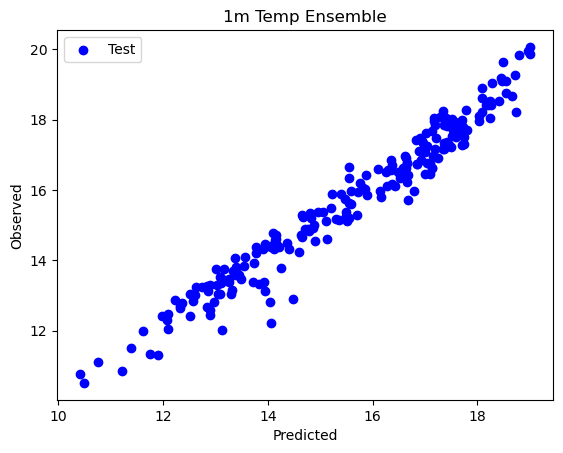

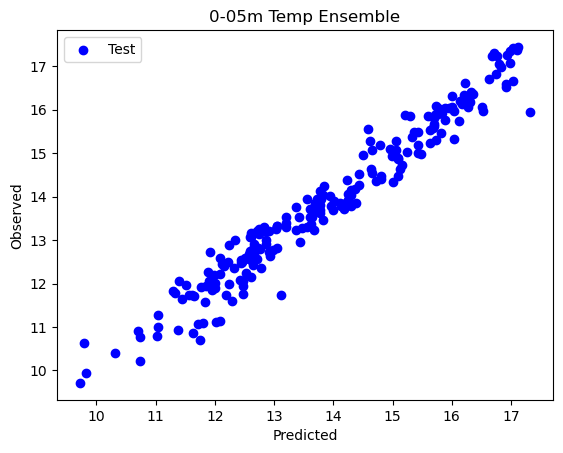

In [14]:
create_scatter_plot_test("1m Temp Ensemble", test["ts_cv_ensemble_pred_1m"], test["mean_1m_temp_degC"])
create_scatter_plot_test("0-05m Temp Ensemble", test["ts_cv_ensemble_pred_05m"], test["mean_0_5m_temp_degC"])

In [15]:
# Ensure 'date' is a datetime column
test['date'] = pd.to_datetime(test['date'])

# Extract unique years
years = test['date'].dt.year.unique()


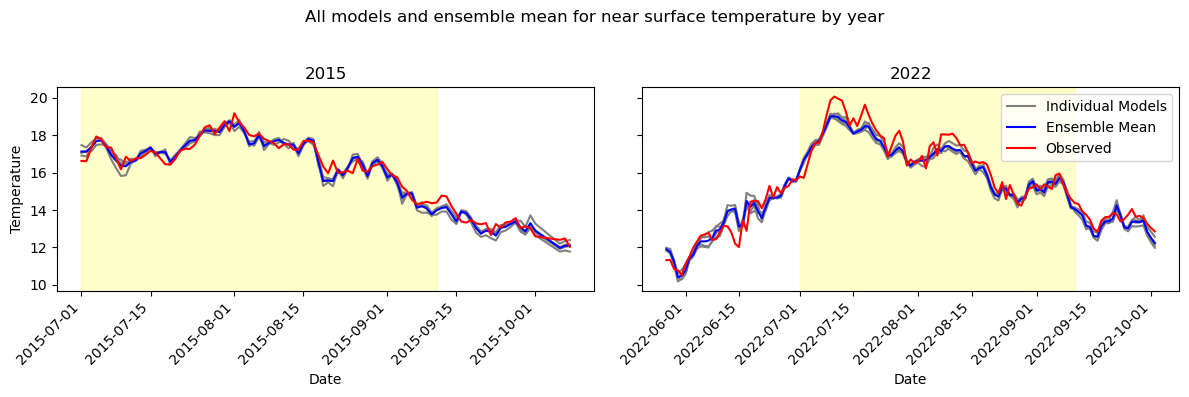

In [16]:
# Create a subplot for each year
fig, axes = plt.subplots(nrows=1, ncols=len(years), figsize=(12, 4), sharey=True)

# If only one year, make axes iterable
if len(years) == 1:
    axes = [axes]

for i, year in enumerate(years):
    yearly_data = test[test['date'].dt.year == year]

    axes[i].plot(yearly_data['date'], yearly_data["pred_1m_1"], label="Individual Models", color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["pred_1m_2"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["pred_1m_3"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["pred_1m_4"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["ts_cv_ensemble_pred_1m"], label="Ensemble Mean", color='blue')
    axes[i].plot(yearly_data['date'], yearly_data["mean_1m_temp_degC"], label="Observed", color='red')

    # Add shading for July 1 to Sept 11
    start = pd.to_datetime(f"{year}-07-01")
    end = pd.to_datetime(f"{year}-09-11")
    axes[i].axvspan(start, end, color='yellow', alpha=0.2)

    axes[i].set_title(f"{year}")
    axes[i].set_xlabel("Date")
    if i == 0:
        axes[i].set_ylabel("Temperature")
            
    for label in axes[i].get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')  # Align to end at the tick

# Add legend only to the last plot
axes[-1].legend(loc='upper right')
fig.suptitle("All models and ensemble mean for near surface temperature by year")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

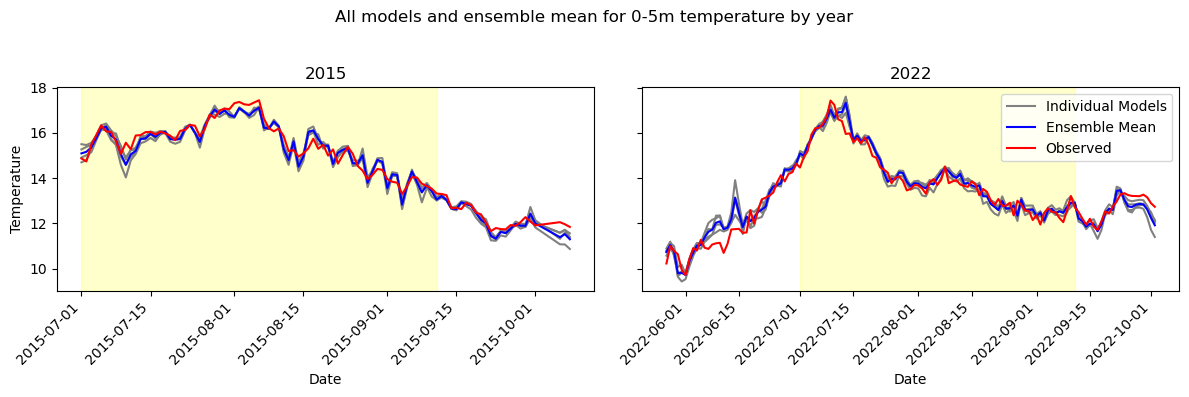

In [17]:
# Create a subplot for each year
fig, axes = plt.subplots(nrows=1, ncols=len(years), figsize=(12, 4), sharey=True)

# If only one year, make axes iterable
if len(years) == 1:
    axes = [axes]
    
for i, year in enumerate(years):
    yearly_data = test[test['date'].dt.year == year]

    axes[i].plot(yearly_data['date'], yearly_data["pred_05m_1"], label="Individual Models", color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["pred_05m_2"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["pred_05m_3"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["pred_05m_4"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["ts_cv_ensemble_pred_05m"], label="Ensemble Mean", color='blue')
    axes[i].plot(yearly_data['date'], yearly_data["mean_0_5m_temp_degC"], label="Observed", color='red')

    # Add shading for July 1 to Sept 11
    start = pd.to_datetime(f"{year}-07-01")
    end = pd.to_datetime(f"{year}-09-11")
    axes[i].axvspan(start, end, color='yellow', alpha=0.2)

    axes[i].set_title(f"{year}")
    axes[i].set_xlabel("Date")
    if i == 0:
        axes[i].set_ylabel("Temperature")
    

    for label in axes[i].get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')  # Align to end at the tick
            


# Add legend only to the last plot
axes[-1].legend(loc='upper right')
fig.suptitle("All models and ensemble mean for 0-5m temperature by year")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

These actually look quite good. While the model doesn't capture the highest values at 1m, there were zero instances in the training/validation set with values that high, so it's not surprising that the model doesn't capture them. The model does a good job of capturing the general trends in the data and does very well with the high 0-5m values.


# Check differences in value from pumping changes

And now let's see how much of a difference there is between the control, no pump and full pump operation

In [18]:
control_preds = test[['pred_1m_1', 'pred_1m_2', 'pred_1m_3', 'pred_1m_4',
                      'pred_05m_1', 'pred_05m_2', 'pred_05m_3', 'pred_05m_4']]
nopump_preds = test_nopump[['pred_1m_1', 'pred_1m_2', 'pred_1m_3', 'pred_1m_4',
                      'pred_05m_1', 'pred_05m_2', 'pred_05m_3', 'pred_05m_4']]
midpump_preds = test_midpump[['pred_1m_1', 'pred_1m_2', 'pred_1m_3', 'pred_1m_4',
                      'pred_05m_1', 'pred_05m_2', 'pred_05m_3', 'pred_05m_4']]
fullpump_preds = test_fullpump[['pred_1m_1', 'pred_1m_2', 'pred_1m_3', 'pred_1m_4',
                      'pred_05m_1', 'pred_05m_2', 'pred_05m_3', 'pred_05m_4']]

turn_off_pump_diff = nopump_preds - control_preds
turn_off_pump_diff['date'] = test['date']
mid_pump_diff = midpump_preds - control_preds
mid_pump_diff['date'] = test['date']
full_on_pump_diff = fullpump_preds - control_preds
full_on_pump_diff['date'] = test['date']


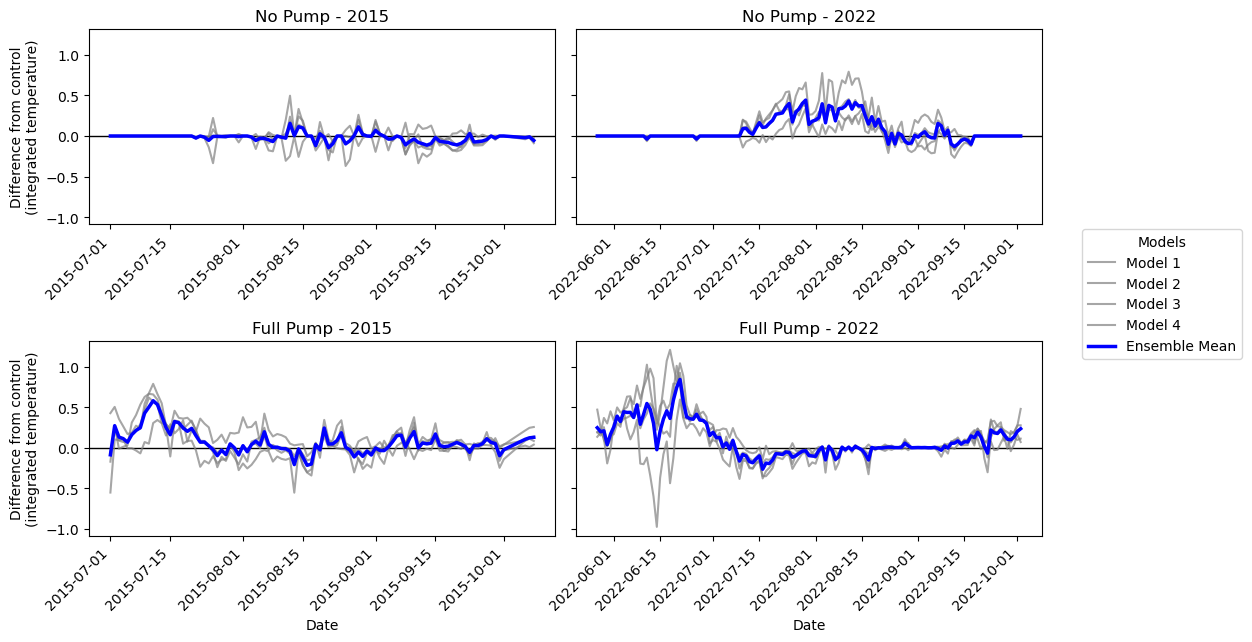

In [27]:
# Extract unique years
years = [2015, 2022]
# Reorder ops so "no pump" is first (top row)
ops = ["no pump", "full pump"]

# Create 2x2 subplots: rows = ops, cols = years
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 6), sharey=True)

for row_idx, op in enumerate(ops):
    for col_idx, year in enumerate(years):
        ax = axes[row_idx, col_idx]

        # Select appropriate dataframe
        if op == "no pump":
            selected_data = turn_off_pump_diff
        else:
            selected_data = full_on_pump_diff

        # Filter by year
        selected_data["date"] = pd.to_datetime(selected_data["date"])
        data_year = selected_data[selected_data["date"].dt.year == year].copy()

        ax.axhline(0, color='black', linewidth=1, zorder=0)

        # Plot individual model predictions
        lines = []
        model_cols = ["pred_1m_1", "pred_1m_2", "pred_1m_3", "pred_1m_4"]
        for col in model_cols:
            line, = ax.plot(data_year["date"], data_year[col], color='grey', alpha=0.7)
            lines.append(line)

        # Plot ensemble mean
        data_year["ensemble_mean"] = data_year[model_cols].mean(axis=1)
        ax.plot(data_year["date"], data_year["ensemble_mean"], color='blue', linewidth=2.5, label="Ensemble Mean")

        # Capture one set of lines for external legend
        if row_idx == 0 and col_idx == 0:
            lines_for_legend = lines
            ensemble_line = ax.lines[-1]  # Last line is the ensemble mean

        ax.set_title(f"{op.title()} - {year}")
        if row_idx == 1:
            ax.set_xlabel("Date")
        if col_idx == 0:
            ax.set_ylabel("Difference from control\n(integrated temperature)")

# Create a single external legend
fig.legend(lines_for_legend + [ensemble_line],
           ["Model 1", "Model 2", "Model 3", "Model 4", "Ensemble Mean"],
           loc="center left", bbox_to_anchor=(0.9, 0.5), title="Models")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space on right for legend
plt.subplots_adjust(hspace=0.6)  # Adjust vertical spacing between rows

# Rotate tick labels
for ax_row in axes:
    for ax in ax_row:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_horizontalalignment('right')


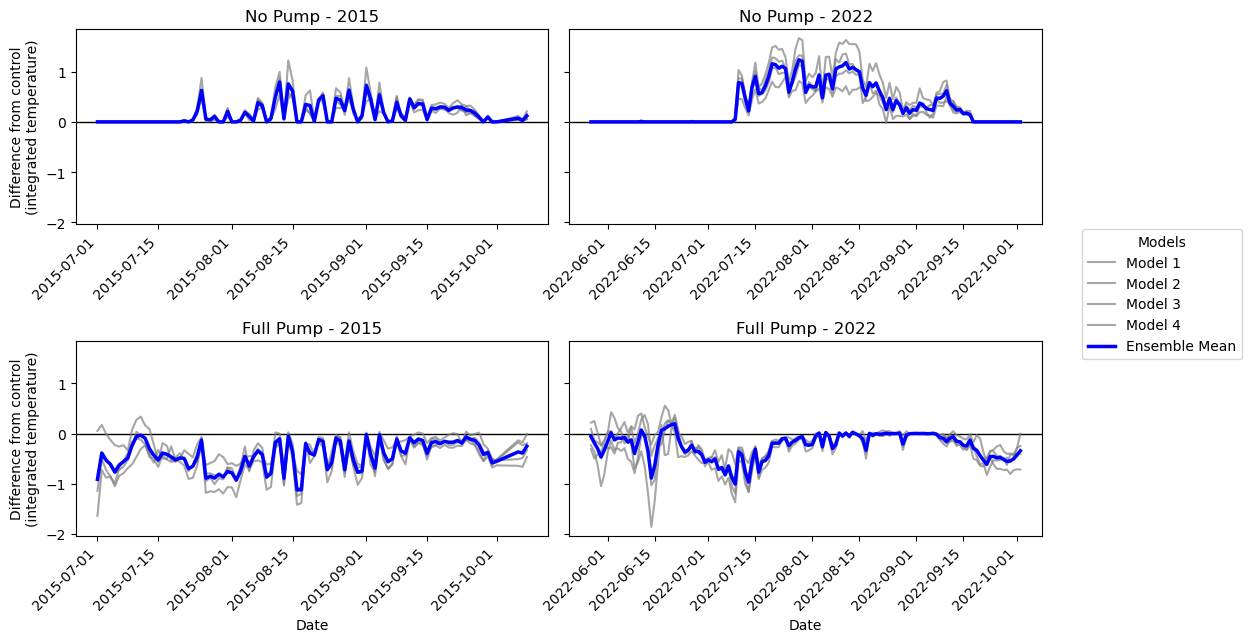

In [26]:
# Reorder ops so "no pump" is first (top row)
ops = ["no pump", "full pump"]

# Create 2x2 subplots: rows = ops, cols = years
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 6), sharey=True)

for row_idx, op in enumerate(ops):
    for col_idx, year in enumerate(years):
        ax = axes[row_idx, col_idx]

        # Select appropriate dataframe
        if op == "no pump":
            selected_data = turn_off_pump_diff
        else:
            selected_data = full_on_pump_diff

        # Filter by year
        selected_data["date"] = pd.to_datetime(selected_data["date"])
        data_year = selected_data[selected_data["date"].dt.year == year].copy()

        ax.axhline(0, color='black', linewidth=1, zorder=0)

        # Plot individual model predictions
        lines = []
        model_cols = ["pred_05m_1", "pred_05m_2", "pred_05m_3", "pred_05m_4"]
        for col in model_cols:
            line, = ax.plot(data_year["date"], data_year[col], color='grey', alpha=0.7)
            lines.append(line)

        # Plot ensemble mean
        data_year["ensemble_mean"] = data_year[model_cols].mean(axis=1)
        ax.plot(data_year["date"], data_year["ensemble_mean"], color='blue', linewidth=2.5, label="Ensemble Mean")

        # Capture one set of lines for external legend
        if row_idx == 0 and col_idx == 0:
            lines_for_legend = lines
            ensemble_line = ax.lines[-1]  # Last line is the ensemble mean

        ax.set_title(f"{op.title()} - {year}")
        if row_idx == 1:
            ax.set_xlabel("Date")
        if col_idx == 0:
            ax.set_ylabel("Difference from control\n(integrated temperature)")

# Create a single external legend
fig.legend(lines_for_legend + [ensemble_line],
           ["Model 1", "Model 2", "Model 3", "Model 4", "Ensemble Mean"],
           loc="center left", bbox_to_anchor=(0.9, 0.5), title="Models")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space on right for legend
plt.subplots_adjust(hspace=0.6)  # Adjust vertical spacing between rows

# Rotate tick labels
for ax_row in axes:
    for ax in ax_row:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_horizontalalignment('right')


Let's actually make one more plot here. It's going to have a few rows of data:

min/max pumping in training
difference between control and alternate
alternate change in temp 1m
alternate change in temp integrated

First we need to summarize the training data to get the min/max values
Then calculate the difference in average cfs
then plot the two differences in temp

We just want data in the training dataset

In [28]:
all_data = pd.read_csv("/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/data/flow_daily.csv")

# make sure 'date' column is datetime
all_data['date'] = pd.to_datetime(all_data['date'])

# remove 2015, 2022, 2025
training_flow = all_data[~all_data['date'].dt.year.isin([2015, 2022, 2025])].copy()


Further, we want to make sure the dates are in the training dataset!

In [29]:
training_dates = pd.concat([pd.read_csv("/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/operational_model/data/training_1.csv"),
                           pd.read_csv("/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/operational_model/data/validation_1.csv")])
training_dates['date'] = pd.to_datetime(training_dates['date'])
training_flow = training_flow[training_flow['date'].isin(training_dates['date'])]

It's not the most precise way of doing things, but for the sake of simplicity, we want the min/max per calendar day - we'll use day of year for this.

In [30]:
# add day of year column
training_flow.loc[:, 'doy'] = training_flow['date'].dt.dayofyear

# group by day of year and summarize
summary = training_flow.groupby('doy')['pump_cfs'].agg(
    min_pump='min',
    max_pump='max',
    mean_pump='mean',
    n='count'
).reset_index()

# add quantiles
quant_summary = training_flow.groupby('doy')['pump_cfs'].quantile([0.25, 0.5, 0.75]).unstack()
quant_summary.columns = ['q25', 'q50', 'q75']
quant_summary = quant_summary.reset_index()

# merge 
full_summary = pd.merge(summary, quant_summary, on='doy')



And now apply that to the two test years for visualization.

In [31]:
summary_2022 = full_summary.copy()
summary_2015 = full_summary.copy()
summary_2022['year'] = 2022
summary_2015['year'] = 2015

summary_2022['date'] = pd.to_datetime(summary_2022['year'].astype(str), format='%Y') + pd.to_timedelta(summary_2022['doy'] - 1, unit='D')
summary_2015['date'] = pd.to_datetime(summary_2015['year'].astype(str), format='%Y') + pd.to_timedelta(summary_2015['doy'] - 1, unit='D')

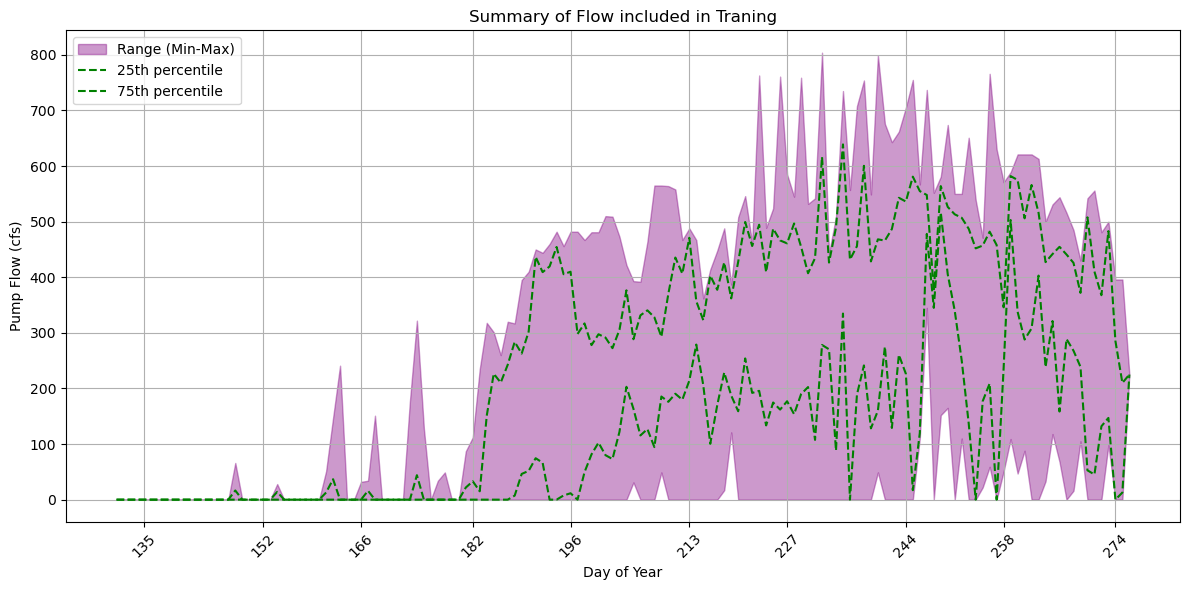

In [32]:
# set up plot with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# plot min/max as shaded range
ax1.fill_between(summary_2015['date'], summary_2015['min_pump'], summary_2015['max_pump'], 
                 color='purple', alpha=0.4, label='Range (Min-Max)')
ax1.set_ylabel("Pump Flow (cfs)")
ax1.set_xlabel("Day of Year")
ax1.set_title("Summary of Flow included in Traning")

# add quantiles
ax1.plot(summary_2015['date'], summary_2015['q25'], color='green', linestyle='--', label='25th percentile')
ax1.plot(summary_2015['date'], summary_2015['q75'], color='green', linestyle='--', label='75th percentile')

# Create tick positions on the 1st and 15th of each month
tick_positions = pd.date_range(start=summary_2015['date'].min(), 
                               end=summary_2015['date'].max(), 
                               freq='D')
tick_positions = tick_positions[tick_positions.day.isin([1, 15])]

# Get corresponding day-of-year labels
tick_labels = [(d - pd.Timestamp(year=d.year, month=1, day=1)).days + 1 for d in tick_positions]

# Apply to your axis
ax1.set_xticks(tick_positions)
ax1.set_xticklabels(tick_labels)

# Set custom labels
ax1.set_xticklabels(tick_labels)

# Set individual legends
ax1.legend(loc='upper left')
#ax2.legend(loc='upper right')

# X-axis formatting
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

In [33]:
def plot_pump_summary(year, operation, operation_value,
                      full_on_pump_diff, mid_pump_diff, turn_off_pump_diff, all_data, summary_data):
    """
    Plot 4-row summary for given year and operation.
    
    Parameters:
    - year: int, e.g. 2015
    - operation: str, "full pump" or "no pump"
    - operation_value: int, cfs in pumping regime
    - full_on_pump_diff: DataFrame with full pump differenced data
    - mid_pump_diff: DataFrame with mid (220) pump differenced data
    - turn_off_pump_diff: DataFrame with no pump differenced data
    - all_data: DataFrame with 'pump_cfs' data including dates
    - summary_data: DataFrame with summary stats (min_pump, max_pump, q25, q75) and 'date'
    """
    # Select the right prediction dataframe based on operation
    if operation.lower() == "full pump":
        selected_data = full_on_pump_diff.copy()
    elif operation.lower() == "mid pump":
        selected_data = mid_pump_diff.copy()
    elif operation.lower() == "no pump":
        selected_data = turn_off_pump_diff.copy()
    else:
        raise ValueError("Operation must be 'full pump' or 'no pump'")
    
    # Prepare prediction data for the specified year
    selected_data["date"] = pd.to_datetime(selected_data["date"])
    data_year = selected_data[selected_data["date"].dt.year == year].copy()
    
    # Prepare pumping flow data for the specified year
    pump_on = all_data.copy()
    pump_on["date"] = pd.to_datetime(pump_on["date"])
    pump_on_year = pump_on[pump_on["date"].dt.year == year]
    
    flow_only = pump_on_year[['date', 'pump_cfs']].copy()
    flow_only['flow_diff'] = operation_value - flow_only['pump_cfs']
    
    # Prepare summary data (already assumed for correct year, or filter here)
    summary_year = summary_data[summary_data["date"].dt.year == year]
    
    # Set up 4-row plot
    fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 10), sharex=True)
    
    # ---- TOP PLOT: Flow Summary ----
    ax0 = axes[0]
    ax0.axhline(operation_value, color='black', linewidth=1, zorder=0, linestyle='--')
    ax0.fill_between(summary_year['date'], summary_year['min_pump'], summary_year['max_pump'], 
                     color='purple', alpha=0.4, label='Range (Min-Max)')
    ax0.plot(summary_year['date'], summary_year['q25'], color='green', linestyle='--', label='25th percentile')
    ax0.plot(summary_year['date'], summary_year['q75'], color='green', linestyle='--', label='75th percentile')
    ax0.set_ylabel("Pump Flow (cfs)")
    ax0.set_title(f"Summary of Pump Operations in Training Data")
    ax0.legend(loc='upper left')
    ax0.tick_params(labelbottom=False)
    
    # ---- SECOND PLOT: Difference between operation and actual ----
    ax1 = axes[1]
    ax1.axhline(0, color='black', linewidth=1, zorder=0)
    ax1.fill_between(flow_only['date'], 0, flow_only['flow_diff'], 
                     color='blue', alpha=0.4)
    ax1.set_ylabel("Difference in Pump Flow (cfs)")
    ax1.set_title(f"Change to Pump between Observed and {operation_value} cfs")
    
    # ---- THIRD PLOT: 1m Predictions ----
    ax2 = axes[2]
    ax2.axhline(0, color='black', linewidth=1, zorder=0)
    lines_1m = []
    model_cols_1m = ["pred_1m_1", "pred_1m_2", "pred_1m_3", "pred_1m_4"]
    for col in model_cols_1m:
        line, = ax2.plot(data_year["date"], data_year[col], color='grey', alpha=0.7)
        lines_1m.append(line)
    
    # Add ensemble mean for 1m
    data_year["ensemble_1m"] = data_year[model_cols_1m].mean(axis=1)
    ensemble_1m_line, = ax2.plot(data_year["date"], data_year["ensemble_1m"], 
                                 color='blue', linewidth=2.5, label="Ensemble Mean")

    ax2.set_ylabel("Diff from Control\n(1m Temp)")
    ax2.set_title(f"{year}: {operation.title()} - 1m Temperature Models")
    
    # ---- BOTTOM PLOT: 0-5m Predictions ----
    ax3 = axes[3]
    ax3.axhline(0, color='black', linewidth=1, zorder=0)
    lines_05m = []
    model_cols_05m = ["pred_05m_1", "pred_05m_2", "pred_05m_3", "pred_05m_4"]
    for col in model_cols_05m:
        line, = ax3.plot(data_year["date"], data_year[col], color='grey', alpha=0.7)
        lines_05m.append(line)

    # Add ensemble mean for 0–5m
    data_year["ensemble_05m"] = data_year[model_cols_05m].mean(axis=1)
    ensemble_05m_line, = ax3.plot(data_year["date"], data_year["ensemble_05m"], 
                                  color='blue', linewidth=2.5, label="Ensemble Mean")

    ax3.set_ylabel("Diff from Control\n(Integrated Temp)")
    ax3.set_title(f"{year}: {operation.title()} - Integrated Temperature Models")
    ax3.set_xlabel("Date")
    
    # Format x-axis labels for better appearance
    for ax in [ax1, ax2, ax3]:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_horizontalalignment('right')
    
    # Add external legend
    fig.legend(lines_1m + [ensemble_1m_line],
               ["Model 1", "Model 2", "Model 3", "Model 4", "Ensemble Mean"],
               loc="center left", bbox_to_anchor=(0.91, 0.5), title="Models")
    
    # Limit x-axis to summary data range
    xmin = summary_year['date'].min()
    xmax = summary_year['date'].max()
    for ax in axes:
        ax.set_xlim([xmin, xmax])
    
    plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for legend
    plt.subplots_adjust(hspace=0.4)
    plt.show()


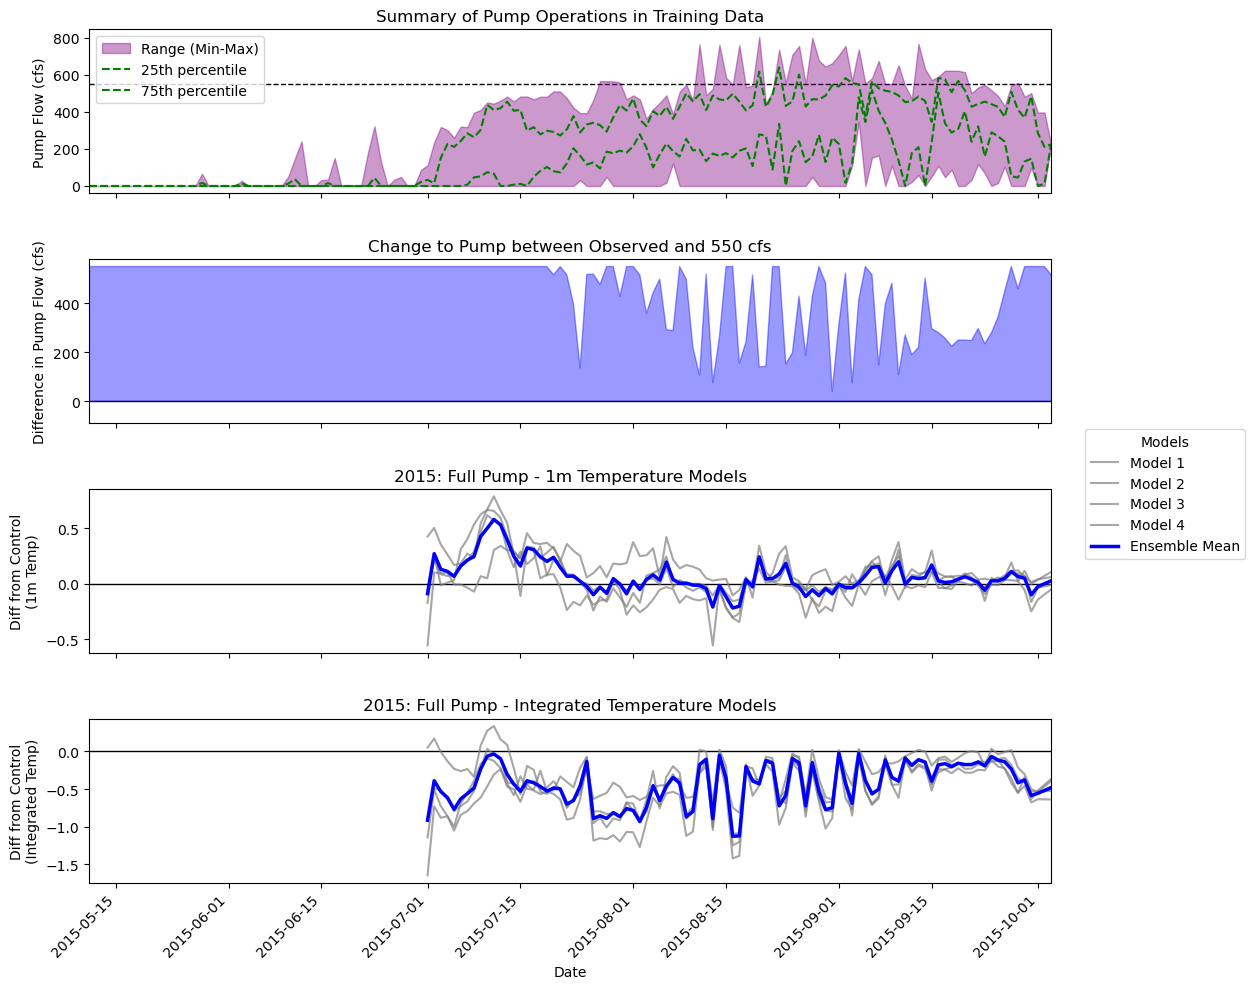

In [26]:
plot_pump_summary(2015, "full pump", 550, full_on_pump_diff, mid_pump_diff, turn_off_pump_diff, all_data, summary_2015)


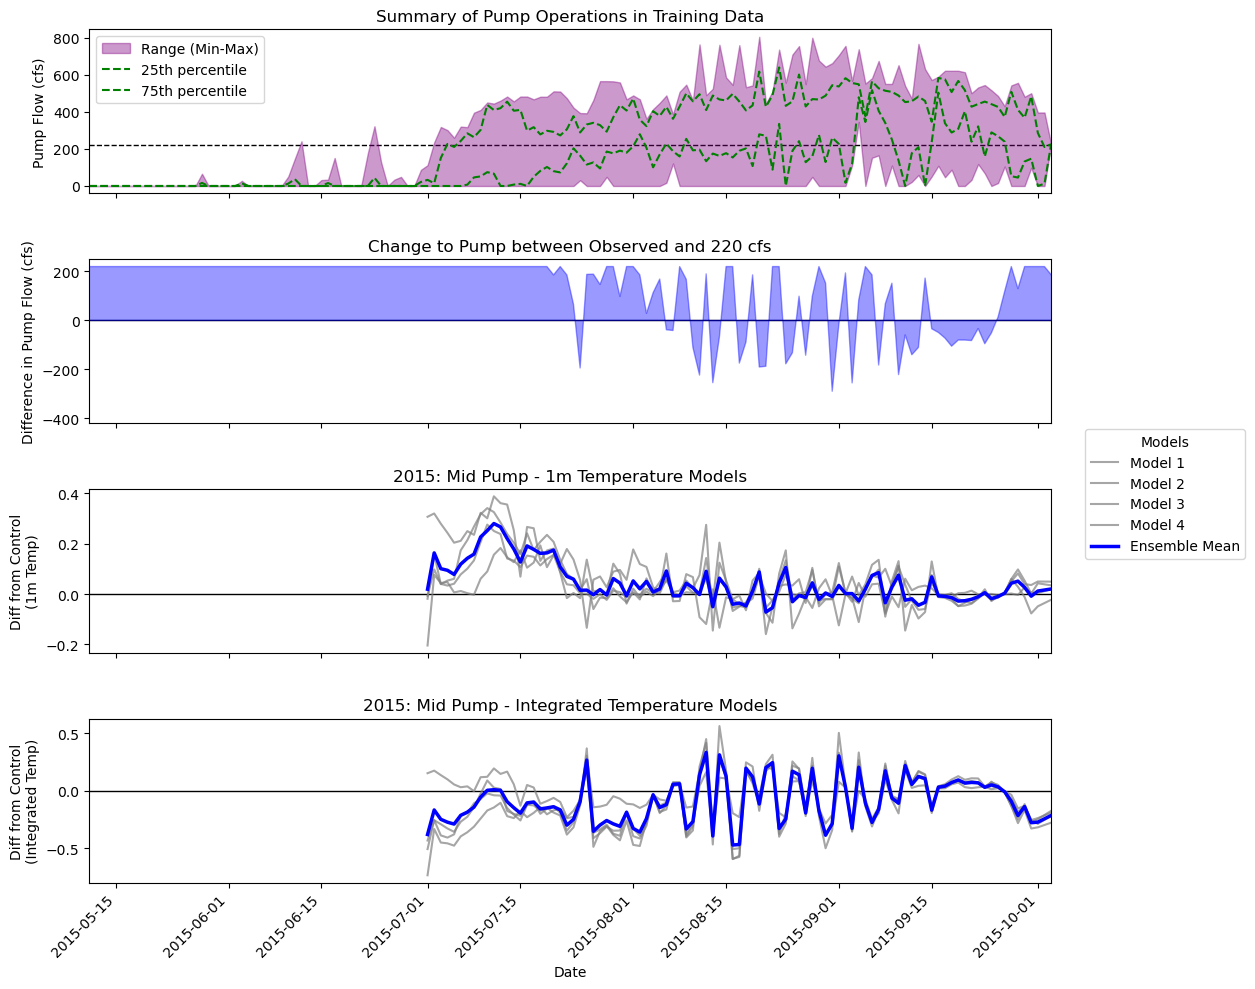

In [27]:
plot_pump_summary(2015, "mid pump", 220, full_on_pump_diff, mid_pump_diff, turn_off_pump_diff, all_data, summary_2015)


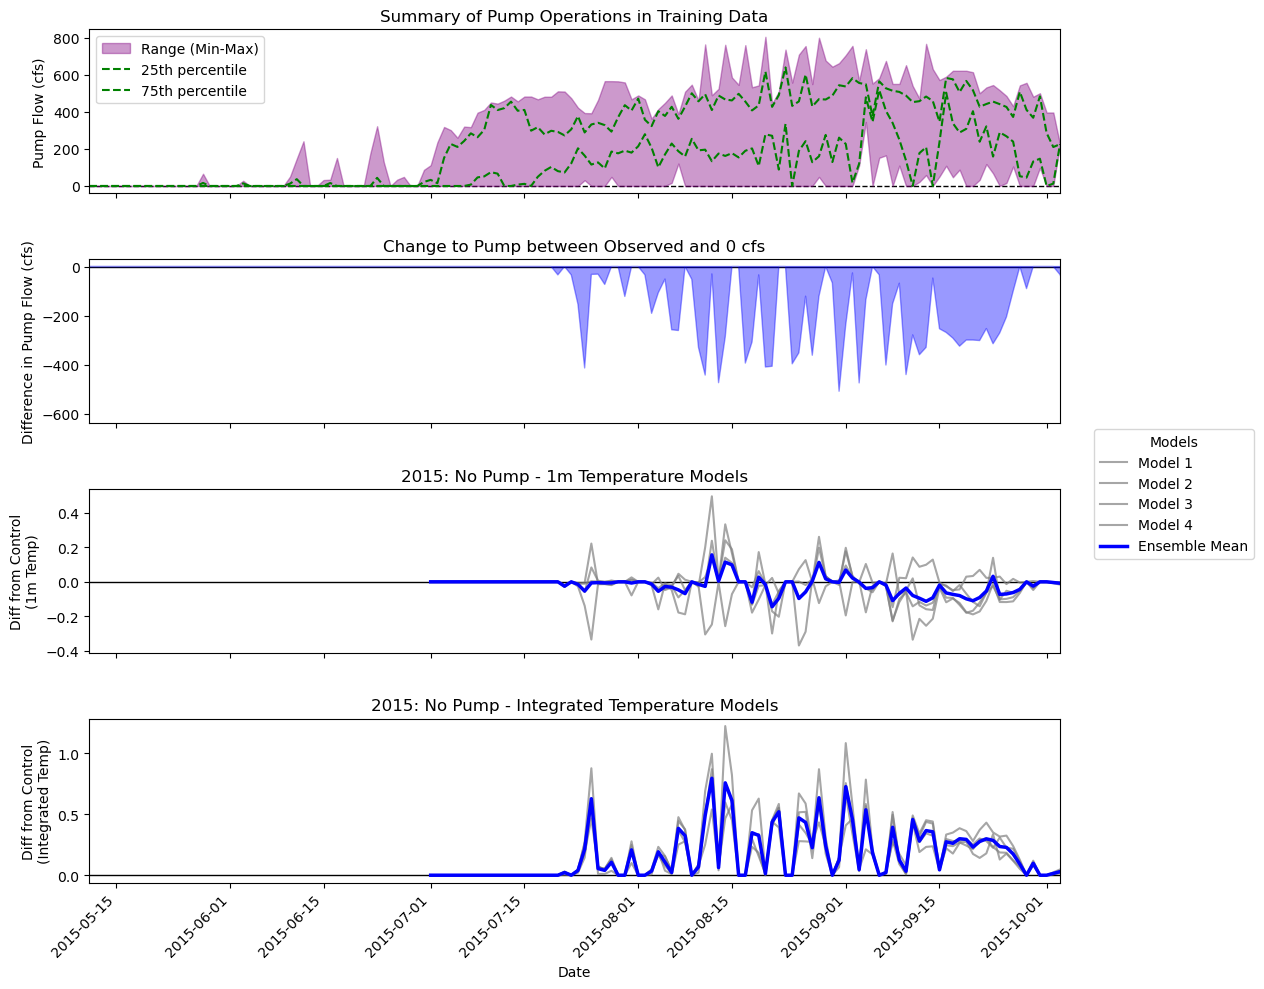

In [28]:
plot_pump_summary(2015, "no pump", 0, full_on_pump_diff, mid_pump_diff, turn_off_pump_diff, all_data, summary_2015)


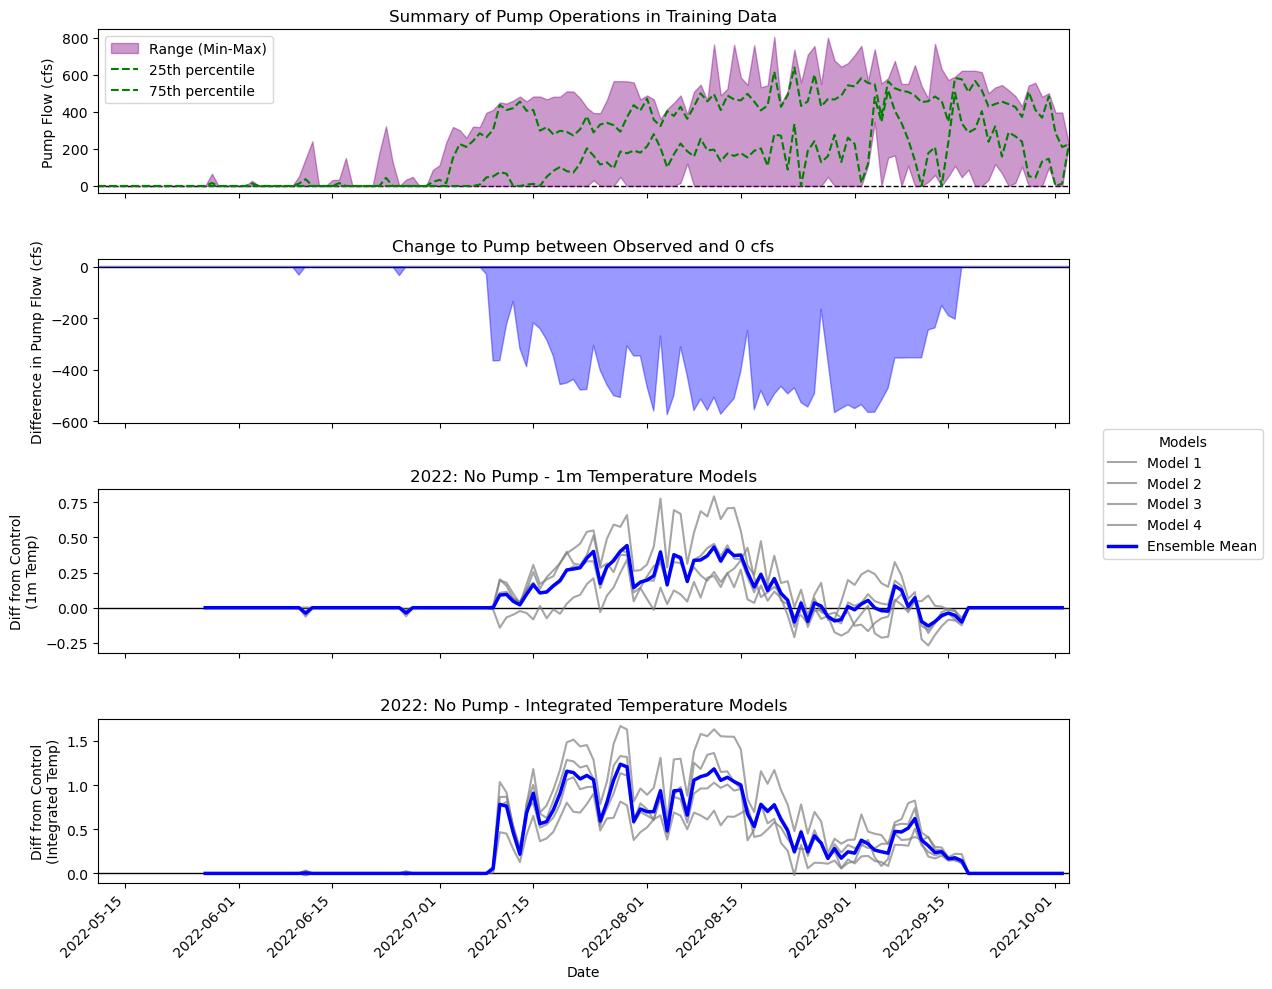

In [29]:
plot_pump_summary(2022, "no pump", 0, full_on_pump_diff, mid_pump_diff, turn_off_pump_diff, all_data, summary_2022)


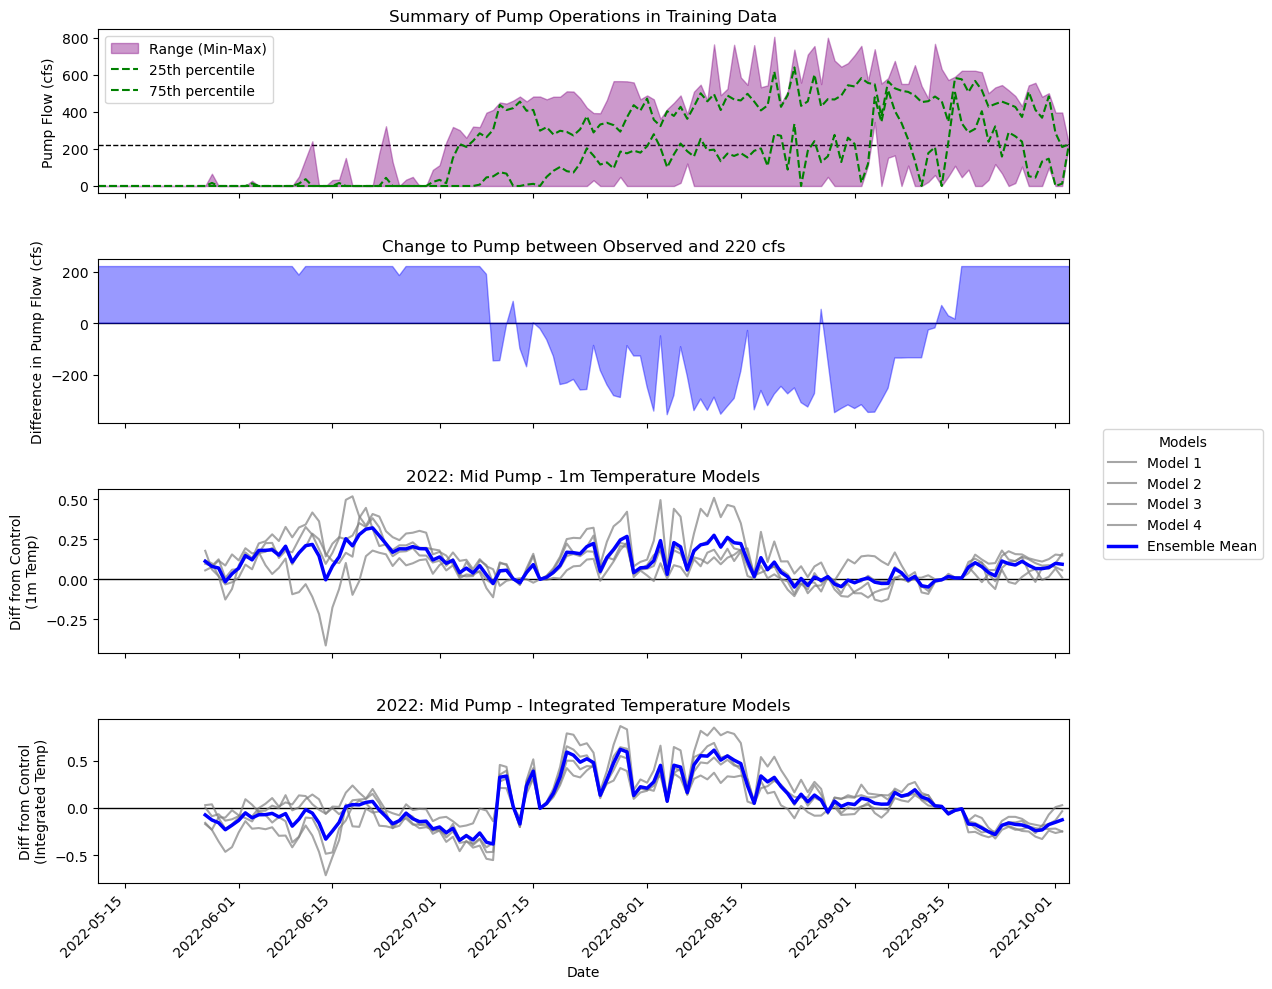

In [30]:
plot_pump_summary(2022, "mid pump", 220, full_on_pump_diff, mid_pump_diff, turn_off_pump_diff, all_data, summary_2022)


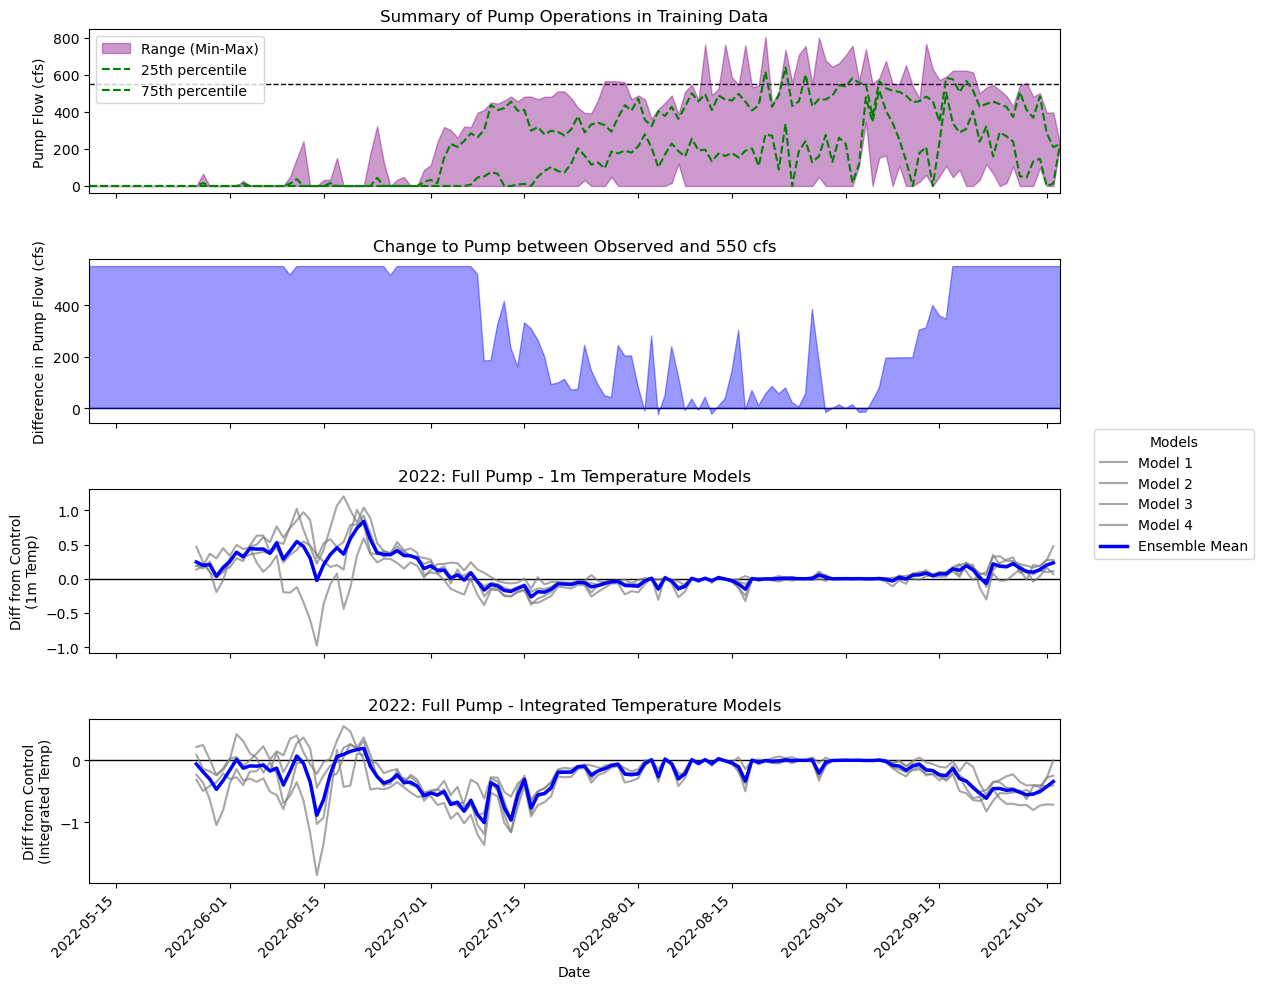

In [31]:
plot_pump_summary(2022, "full pump", 550, full_on_pump_diff, mid_pump_diff, turn_off_pump_diff, all_data, summary_2022)


SUBTRACT 550 PUMP FROM 0 PUMP, THAT'S OUR MAX FOR THE YEAR!

In [34]:
max_pump_change = nopump_preds - fullpump_preds
max_pump_change["date"] = test["date"]

max_pump_change

,pred_1m_1,pred_1m_2,pred_1m_3,pred_1m_4,pred_05m_1,pred_05m_2,pred_05m_3,pred_05m_4,date
0,-0.425075,0.173218,0.554246,0.053265,-0.051543,1.142166,1.643064,0.918505,2015-07-01
1,-0.502312,-0.263950,-0.100911,-0.215389,-0.171603,0.505723,0.727619,0.489725,2015-07-02
2,-0.354020,0.012897,-0.093580,-0.085298,0.007218,0.725688,0.880368,0.514197,2015-07-03
3,-0.262348,-0.010223,-0.100812,-0.070457,0.128783,0.858163,0.858946,0.609231,2015-07-04
4,-0.168265,-0.030549,0.006594,-0.073912,0.229939,0.998809,1.051077,0.790712,2015-07-05
...,...,...,...,...,...,...,...,...,...
220,0.015584,-0.108755,-0.131676,-0.190462,0.627614,0.720631,0.406706,0.478431,2022-09-28
221,-0.203353,-0.063145,0.043914,-0.163793,0.417494,0.805858,0.399598,0.562399,2022-09-29
222,-0.179849,-0.122354,-0.037379,-0.192301,0.426323,0.730138,0.403369,0.464015,2022-09-30
223,-0.269109,-0.094757,-0.162923,-0.274455,0.291978,0.713638,0.421908,0.281037,2022-10-01


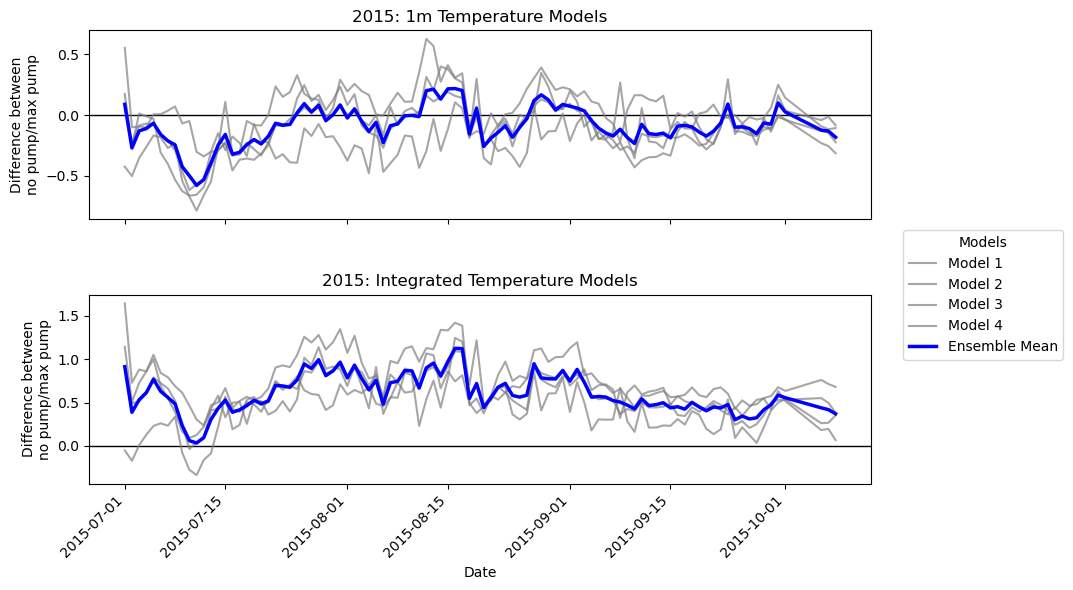

In [35]:
year = 2015

# Prepare prediction data for the specified year
max_pump_change["date"] = pd.to_datetime(max_pump_change["date"])
data_year = max_pump_change[max_pump_change["date"].dt.year == year].copy()

# Set up 2-row plot
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)

# ---- First PLOT: 1m Predictions ----
ax1 = axes[0]
ax1.axhline(0, color='black', linewidth=1, zorder=0)
lines_1m = []
model_cols_1m = ["pred_1m_1", "pred_1m_2", "pred_1m_3", "pred_1m_4"]

for col in model_cols_1m:
    line, = ax1.plot(data_year["date"], data_year[col], color='grey', alpha=0.7)
    lines_1m.append(line)

# Add ensemble mean for 1m
data_year["ensemble_1m"] = data_year[model_cols_1m].mean(axis=1)
ensemble_1m_line, = ax1.plot(data_year["date"], data_year["ensemble_1m"], 
                             color='blue', linewidth=2.5, label="Ensemble Mean")

ax1.set_ylabel("Difference between\nno pump/max pump")
ax1.set_title(f"{year}: 1m Temperature Models")

# ---- Second PLOT: 0-5m Predictions ----
ax2 = axes[1]
ax2.axhline(0, color='black', linewidth=1, zorder=0)
lines_05m = []
model_cols_05m = ["pred_05m_1", "pred_05m_2", "pred_05m_3", "pred_05m_4"]

for col in model_cols_05m:
    line, = ax2.plot(data_year["date"], data_year[col], color='grey', alpha=0.7)
    lines_05m.append(line)

# Add ensemble mean for 0–5m
data_year["ensemble_05m"] = data_year[model_cols_05m].mean(axis=1)
ensemble_05m_line, = ax2.plot(data_year["date"], data_year["ensemble_05m"], 
                              color='blue', linewidth=2.5, label="Ensemble Mean")

ax2.set_ylabel("Difference between\nno pump/max pump")
ax2.set_title(f"{year}: Integrated Temperature Models")
ax2.set_xlabel("Date")

# Format x-axis labels for better appearance
for ax in [ax1, ax2]:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')

# Add external legend
fig.legend(lines_1m + [ensemble_1m_line],
           ["Model 1", "Model 2", "Model 3", "Model 4", "Ensemble Mean"],
           loc="center left", bbox_to_anchor=(0.91, 0.5), title="Models")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for legend
plt.subplots_adjust(hspace=0.4)
plt.show()


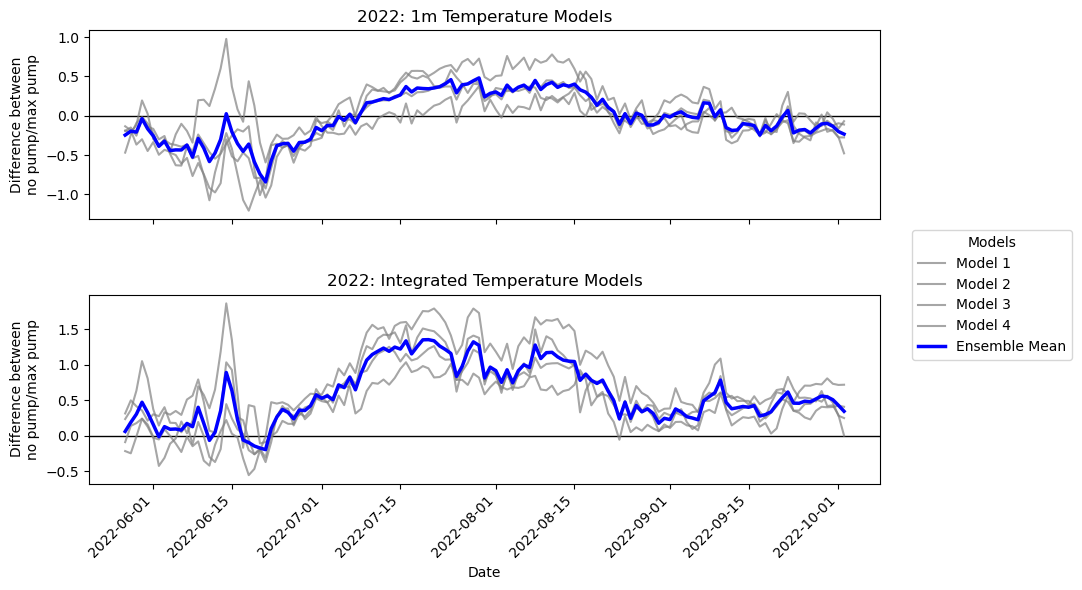

In [36]:
year = 2022

# Prepare prediction data for the specified year
max_pump_change["date"] = pd.to_datetime(max_pump_change["date"])
data_year = max_pump_change[max_pump_change["date"].dt.year == year].copy()

# Set up 2-row plot
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)

# ---- First PLOT: 1m Predictions ----
ax1 = axes[0]
ax1.axhline(0, color='black', linewidth=1, zorder=0)
lines_1m = []
model_cols_1m = ["pred_1m_1", "pred_1m_2", "pred_1m_3", "pred_1m_4"]

for col in model_cols_1m:
    line, = ax1.plot(data_year["date"], data_year[col], color='grey', alpha=0.7)
    lines_1m.append(line)

# Add ensemble mean for 1m
data_year["ensemble_1m"] = data_year[model_cols_1m].mean(axis=1)
ensemble_1m_line, = ax1.plot(data_year["date"], data_year["ensemble_1m"], 
                             color='blue', linewidth=2.5, label="Ensemble Mean")

ax1.set_ylabel("Difference between\nno pump/max pump")
ax1.set_title(f"{year}: 1m Temperature Models")

# ---- Second PLOT: 0-5m Predictions ----
ax2 = axes[1]
ax2.axhline(0, color='black', linewidth=1, zorder=0)
lines_05m = []
model_cols_05m = ["pred_05m_1", "pred_05m_2", "pred_05m_3", "pred_05m_4"]

for col in model_cols_05m:
    line, = ax2.plot(data_year["date"], data_year[col], color='grey', alpha=0.7)
    lines_05m.append(line)

# Add ensemble mean for 0–5m
data_year["ensemble_05m"] = data_year[model_cols_05m].mean(axis=1)
ensemble_05m_line, = ax2.plot(data_year["date"], data_year["ensemble_05m"], 
                              color='blue', linewidth=2.5, label="Ensemble Mean")

ax2.set_ylabel("Difference between\nno pump/max pump")
ax2.set_title(f"{year}: Integrated Temperature Models")
ax2.set_xlabel("Date")

# Format x-axis labels for better appearance
for ax in [ax1, ax2]:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')

# Add external legend
fig.legend(lines_1m + [ensemble_1m_line],
           ["Model 1", "Model 2", "Model 3", "Model 4", "Ensemble Mean"],
           loc="center left", bbox_to_anchor=(0.91, 0.5), title="Models")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for legend
plt.subplots_adjust(hspace=0.4)
plt.show()


## Create timeseries residual plot

Calculate residuals

In [35]:
test['res_1m_1'] = (test['pred_1m_1']) - (test['mean_1m_temp_degC'])
test['res_1m_2'] = (test['pred_1m_2']) - (test['mean_1m_temp_degC'])
test['res_1m_3'] = (test['pred_1m_3']) - (test['mean_1m_temp_degC'])
test['res_1m_4'] = (test['pred_1m_4']) - (test['mean_1m_temp_degC'])
test['res_1m_ensemble'] = (test['ts_cv_ensemble_pred_1m']) - (test['mean_1m_temp_degC'])

test['res_05m_1'] = test['pred_05m_1'] - test['mean_0_5m_temp_degC']
test['res_05m_2'] = test['pred_05m_2'] - test['mean_0_5m_temp_degC']
test['res_05m_3'] = test['pred_05m_3'] - test['mean_0_5m_temp_degC']
test['res_05m_4'] = test['pred_05m_4'] - test['mean_0_5m_temp_degC']
test['res_05m_ensemble'] = test['ts_cv_ensemble_pred_05m'] - test['mean_0_5m_temp_degC']


In [36]:
yit = test.filter(['mean_0_5m_temp_degC', 'mean_1m_temp_degC'])
yit = yit.shift(periods=1).rename(columns={'mean_0_5m_temp_degC': 'yit_mean_0_5m_temp_degC', 
                                     'mean_1m_temp_degC': 'yit_mean_1m_temp_degC'})

test = pd.concat([test, yit], axis=1)
test['res_yit_0_5m'] = test['yit_mean_0_5m_temp_degC'] - test['mean_0_5m_temp_degC']
test['res_yit_1m'] = (test['yit_mean_1m_temp_degC']) - (test['mean_1m_temp_degC'])


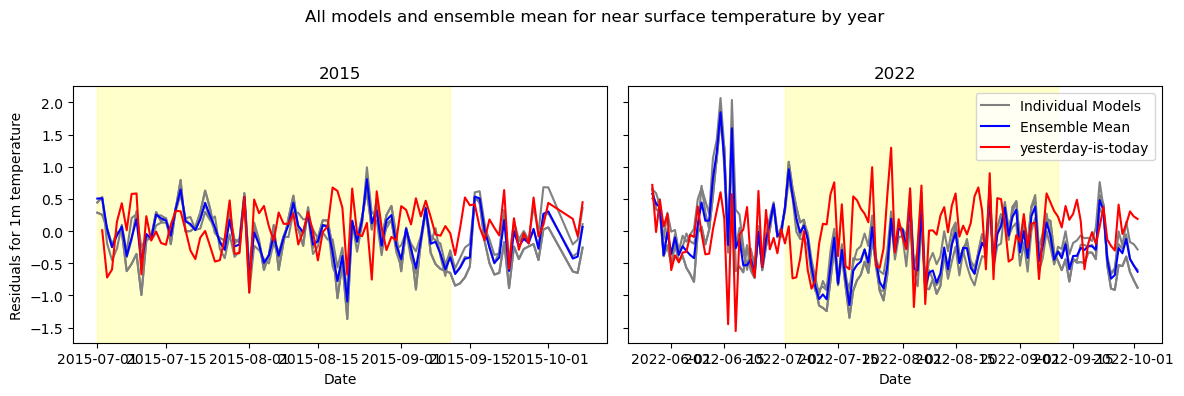

In [37]:
# Create a subplot for each year
fig, axes = plt.subplots(nrows=1, ncols=len(years), figsize=(12, 4), sharey=True)

# If only one year, make axes iterable
if len(years) == 1:
    axes = [axes]
    
for i, year in enumerate(years):
    yearly_data = test[test['date'].dt.year == year]

    axes[i].plot(yearly_data['date'], yearly_data["res_1m_1"], label="Individual Models", color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_1m_1"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_1m_2"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_1m_3"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_1m_ensemble"], label="Ensemble Mean", color='blue')
    axes[i].plot(yearly_data['date'], yearly_data["res_yit_1m"], label="yesterday-is-today", color='red')

    # Add shading for July 1 to Sept 11
    start = pd.to_datetime(f"{year}-07-01")
    end = pd.to_datetime(f"{year}-09-11")
    axes[i].axvspan(start, end, color='yellow', alpha=0.2)

    axes[i].set_title(f"{year}")
    axes[i].set_xlabel("Date")
    if i == 0:
        axes[i].set_ylabel("Residuals for 1m temperature")

# Add legend only to the last plot
axes[-1].legend(loc='upper right')
fig.suptitle("All models and ensemble mean for near surface temperature by year")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


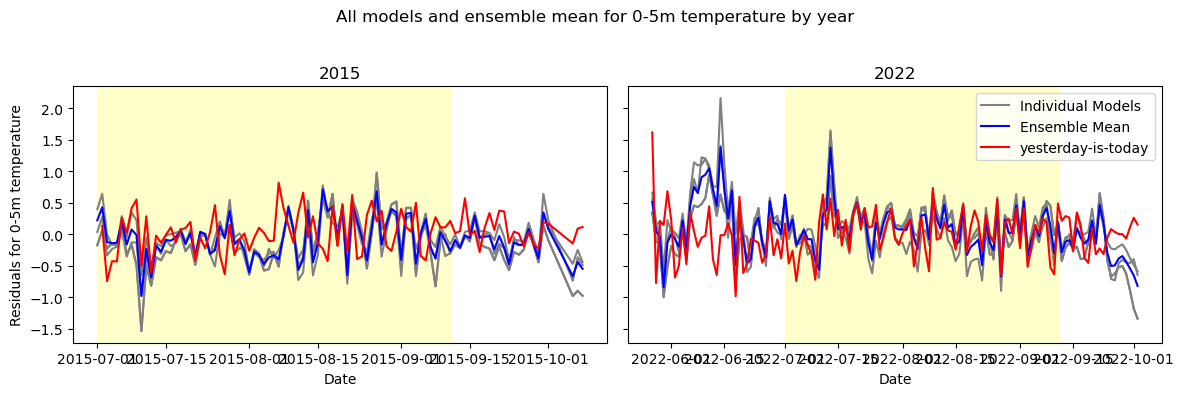

In [38]:
# Create a subplot for each year
fig, axes = plt.subplots(nrows=1, ncols=len(years), figsize=(12, 4), sharey=True)

# If only one year, make axes iterable
if len(years) == 1:
    axes = [axes]
    
for i, year in enumerate(years):
    yearly_data = test[test['date'].dt.year == year]

    axes[i].plot(yearly_data['date'], yearly_data["res_05m_1"], label="Individual Models", color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_05m_1"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_05m_2"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_05m_3"], color='grey')
    axes[i].plot(yearly_data['date'], yearly_data["res_05m_ensemble"], label="Ensemble Mean", color='blue')
    axes[i].plot(yearly_data['date'], yearly_data["res_yit_0_5m"], label="yesterday-is-today", color='red')

    # Add shading for July 1 to Sept 11
    start = pd.to_datetime(f"{year}-07-01")
    end = pd.to_datetime(f"{year}-09-11")
    axes[i].axvspan(start, end, color='yellow', alpha=0.2)

    axes[i].set_title(f"{year}")
    axes[i].set_xlabel("Date")
    if i == 0:
        axes[i].set_ylabel("Residuals for 0-5m temperature")

# Add legend only to the last plot
axes[-1].legend(loc='upper right')
fig.suptitle("All models and ensemble mean for 0-5m temperature by year")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()